In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns

h5ad_file = "/home/catherine/phd/projects/termites/data/znev/combined_no_norm_clustered.h5ad"
adata = sc.read_h5ad(h5ad_file)

cell_type_annot_col = 'paper_cell_type_annotation'



In [7]:
# i got the vg genes by searching vitellogenin in the ncbi znev genome gene list 

with open("/home/catherine/phd/projects/termites/code/znev_analysis/opsin_investigation/caste_gene_diff_analysis/unique_vg_ids.txt", "r") as f:
    vg_list = [line.strip() for line in f]



Plotting for caste: soldier
Plotting for caste: worker
Plotting for caste: queen
Plotting for caste: king


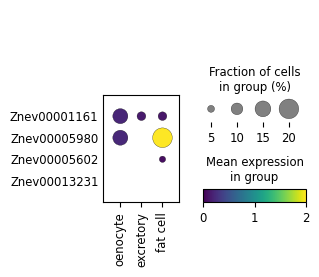

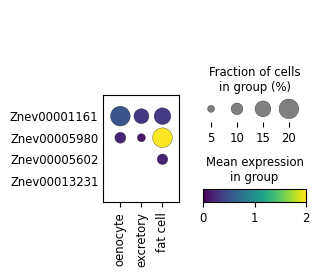

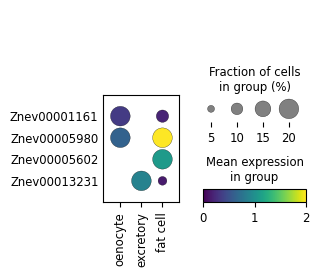

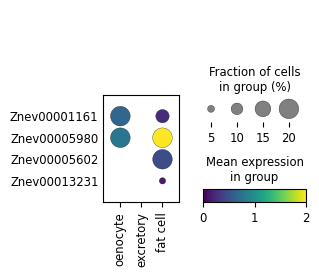

In [8]:
## Figure 4B

import pandas as pd
import scanpy as sc
from collections import defaultdict
import matplotlib.pyplot as plt

gene_display_names_vg = {
    'Znev00001161': 'yl',
    'Znev00005980': 'Vg T1',
    'Znev00005602': 'Vg T2',
    'Znev00013231': 'Vg-1',
}

new_order = ["yl", "Vg T1", "Vg T2", "Vg-1"]

tmp = []
for stub in new_order:
    for gene_id, descr in gene_display_names_vg.items():
        if stub in descr:
            tmp.append(gene_id)

flattened_genes = [g for g in tmp if g in adata.var_names]

cell_type_col = "paper_cell_type_annotation"
two_castes = ["soldier", "worker", "queen", "king"]
chosen_cell_types = ['oenocyte', 'excretory', 'fat cell']

adata_all = adata.copy()
adata_all.obs[cell_type_col] = pd.Categorical(
    adata_all.obs[cell_type_col],
    categories=chosen_cell_types,
    ordered=True
)

sc.settings.figdir = "plots"
sc.settings.file_format_figs = "png"
sc.settings.dpi_save = 600

for caste in two_castes:
    print(f"Plotting for caste: {caste}")

    ad = adata_all[adata_all.obs["caste"] == caste].copy()
    ad.obs[cell_type_col] = pd.Categorical(
        ad.obs[cell_type_col],
        categories=chosen_cell_types,
        ordered=True
    )

    dp = sc.pl.dotplot(
        ad,
        var_names=flattened_genes,
        groupby=cell_type_col,
        categories_order=chosen_cell_types,
        color_map="viridis",
        dot_max=0.20,
        title="",
        swap_axes=True,
        show=False,
        return_fig=True,
        vmax=2,
    )

    ax_dict = dp.get_axes()

    # 🔥 Remove ALL axis labels + ticks
    if "mainplot_ax" in ax_dict:
        ax = ax_dict["mainplot_ax"]
        #ax.set_xticklabels([])
        #ax.set_yticklabels([])
        #ax.set_xlabel("")
        #ax.set_ylabel("")
        ax.tick_params(axis="y", which="both", length=0)

    
    dp.fig.savefig(
        f"plots/dotplot_figure_4B_{caste}.png",
        dpi=600,
        bbox_inches="tight")

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

def plot_abundance_and_expression(
    adata,
    cell_type,
    gene_id,
    cell_type_col="paper_cell_type_annotation",
    caste_col="caste",
    castes=("queen","king","soldier","worker"),
    palette_dict=None,
    figsize=(9, 3.8),
):
    """
    Build a 2-panel figure:
      Left  : % abundance of `cell_type` across castes
      Right : mean expression of `gene_id` in that cell type across castes
    """

    # ---------- Palette ----------
    if palette_dict is None:
        palette = sns.color_palette("Set3", n_colors=4)
        palette_dict = dict(zip(("queen","king","soldier","worker"), palette))

    # ---------- Sanity checks ----------
    if cell_type not in adata.obs[cell_type_col].unique():
        raise ValueError(f"Cell type '{cell_type}' not found in column '{cell_type_col}'.")
    if gene_id not in adata.var_names:
        raise ValueError(f"Gene '{gene_id}' not found in adata.var_names.")

    # ============================================================
    # A) % abundance
    # ============================================================
    data = adata.obs[[caste_col, cell_type_col]].copy()
    cell_counts = data.groupby([caste_col, cell_type_col]).size().reset_index(name='count')
    pivot_table = cell_counts.pivot(index=cell_type_col, columns=caste_col, values='count').fillna(0)

    for c in castes:
        if c not in pivot_table.columns:
            pivot_table[c] = 0

    # enforce column order (fixes "wrong order" issues)
    pivot_table = pivot_table.loc[:, list(castes)]

    total_cells_per_caste = pivot_table.sum(axis=0)
    fraction_table = pivot_table.divide(total_cells_per_caste, axis=1) * 100.0
    pct_series = fraction_table.loc[cell_type, list(castes)].astype(float)

    # ============================================================
    # B) mean expression
    # ============================================================
    ad_ct = adata[adata.obs[cell_type_col] == cell_type]
    expr_vals = []
    for c in castes:
        sub = ad_ct[ad_ct.obs[caste_col] == c]
        if sub.n_obs == 0:
            expr_vals.append(np.nan)
        else:
            x = sc.get.obs_df(sub, keys=[gene_id], use_raw=False, layer=None)[gene_id].to_numpy()
            expr_vals.append(np.mean(x))

    expr_series = pd.Series(expr_vals, index=list(castes), dtype=float)

    # ============================================================
    # C) Plot
    # ============================================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

    # Left: % abundance
    ax1.bar(
        x=np.arange(len(castes)),
        height=pct_series.values,
        color=[palette_dict[c] for c in castes],
        edgecolor="k",
        linewidth=0.8,
        zorder=3
    )
    ax1.set_xticks(np.arange(len(castes)), labels=list(castes))
    ax1.set_ylabel("")
    ax1.set_title(f"")
    y_top = np.nanmax(pct_series.values)
    ax1.set_ylim(0, y_top * 1.15 if np.isfinite(y_top) and y_top > 0 else 1.0)
    ax1.grid(True, axis="y", alpha=0.3, zorder=0)

    # Right: mean expression
    ax2.bar(
        x=np.arange(len(castes)),
        height=expr_series.values,
        color=[palette_dict[c] for c in castes],
        edgecolor="k",
        linewidth=0.8,
        zorder=3
    )
    ax2.set_xticks(np.arange(len(castes)), labels=list(castes))
    ax2.set_ylabel("")
    ax2.set_title(f"")
    y_top_expr = np.nanmax(expr_series.values)
    ax2.set_ylim(0, y_top_expr * 1.15 if np.isfinite(y_top_expr) and y_top_expr > 0 else 1.0)
    ax2.grid(True, axis="y", alpha=0.3, zorder=0)

    return fig, (ax1, ax2)


/tmp/ipykernel_8596/2053715350.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = data.groupby([caste_col, cell_type_col]).size().reset_index(name='count')


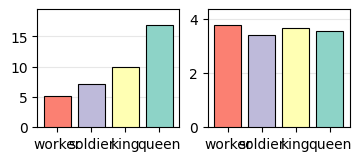

In [10]:
### Figure 4 C

# palette
palette = sns.color_palette("Set3", n_colors=4)
palette_dict = {
    "worker":  palette[3],  # red-ish
    "soldier": palette[2],  # purple-ish
    "king":    palette[1],  # yellow-ish
    "queen":   palette[0],  # green-ish
}
castes = ["worker", "soldier", "king", "queen"]

# call
fig, axes = plot_abundance_and_expression(
    adata=adata,
    cell_type="fat cell",
    gene_id="Znev00005980",
    cell_type_col="paper_cell_type_annotation",
    caste_col="caste",
    castes=castes,
    palette_dict=palette_dict,
    #annotate=True,
    figsize=(3.5, 1.5)
)
plt.show()


/tmp/ipykernel_8596/3902372208.py:30: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[cell_type_col]):


Plotting for caste: soldier


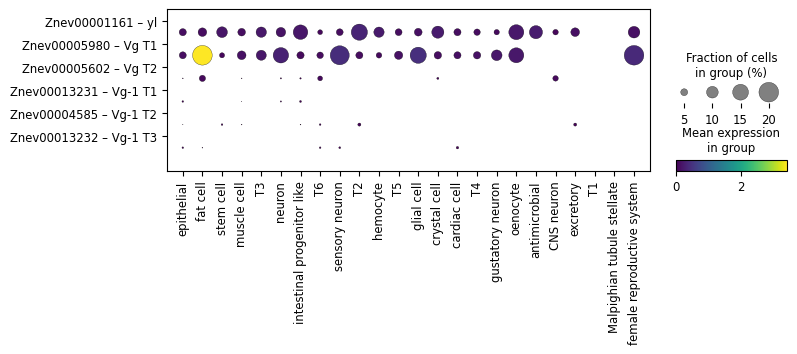

Plotting for caste: worker


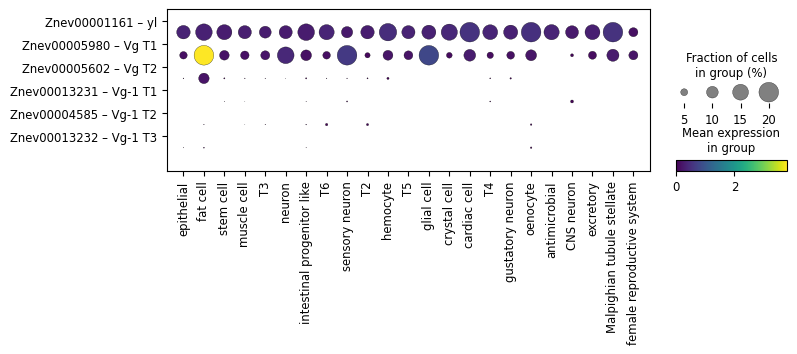

Plotting for caste: queen


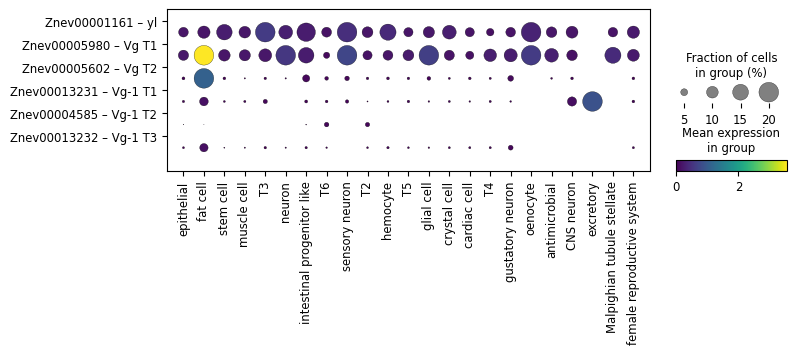

Plotting for caste: king


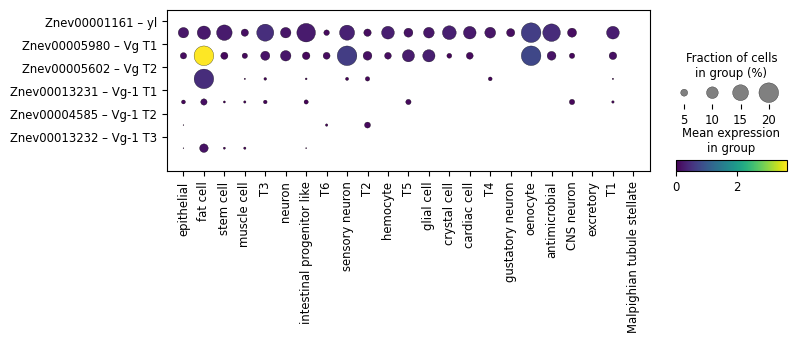

In [11]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

gene_display_names_vg = {
    'Znev00001161': 'yl',
    'Znev00005980': 'Vg T1',
    'Znev00005602': 'Vg T2',
    'Znev00013231': 'Vg-1 T1',
    'Znev00004585': 'Vg-1 T2',
    'Znev00013232': 'Vg-1 T3',
}

new_order = ["yl", "Vg T1", "Vg T2", "Vg-1 T1", "Vg-1 T2", "Vg-1 T3"]

# keep genes in the exact order you want
tmp = []
for stub in new_order:
    for gene_id, descr in gene_display_names_vg.items():
        if stub == descr:
            tmp.append(gene_id)

flattened_genes = [g for g in tmp if g in adata.var_names]

cell_type_col = "paper_cell_type_annotation"
two_castes = ["soldier", "worker", "queen", "king"]
caste_col = "caste"

# global order of cell types
if pd.api.types.is_categorical_dtype(adata.obs[cell_type_col]):
    all_cell_types_order = list(adata.obs[cell_type_col].cat.categories)
else:
    all_cell_types_order = sorted(
        adata.obs[cell_type_col].dropna().astype(str).unique().tolist()
    )

adata_all = adata.copy()
adata_all.obs[cell_type_col] = adata_all.obs[cell_type_col].astype(str)
adata_all.obs[caste_col] = adata_all.obs[caste_col].astype(str)

# build "ID – name" labels for the genes (in the same order as flattened_genes)
gene_labels = [f"{g} – {gene_display_names_vg.get(g, '')}" for g in flattened_genes]

for caste in two_castes:
    print(f"Plotting for caste: {caste}")

    ad = adata_all[adata_all.obs[caste_col] == caste].copy()

    present = set(ad.obs[cell_type_col].dropna().unique().tolist())
    categories_order = [ct for ct in all_cell_types_order if ct in present]

    ad.obs[cell_type_col] = pd.Categorical(
        ad.obs[cell_type_col],
        categories=categories_order,
        ordered=True
    )

    dp = sc.pl.dotplot(
        ad,
        var_names=flattened_genes,
        groupby=cell_type_col,
        categories_order=categories_order,
        color_map="viridis",
        dot_max=0.2,
        figsize=(8.0, 2.1),
        title="",
        swap_axes=True,     # genes are on Y axis now
        show=False,
        return_fig=True,
    )

    ax_dict = dp.get_axes()
    main_ax = ax_dict.get("mainplot_ax", None)

    if main_ax is not None:
        # With swap_axes=True, genes are on the Y axis
        main_ax.set_yticks(range(len(flattened_genes)))
        main_ax.set_yticklabels(gene_labels)

       
    #dp.show()
    plt.show()


In [12]:
import pandas as pd

gene_display_names_vg = {
    'Znev00001161': 'yl',
    'Znev00005980': 'Vg T1',
    'Znev00005602': 'Vg T2',
    'Znev00013231': 'Vg-1 T1',
    'Znev00004585': 'Vg-1 T2',
    'Znev00013232': 'Vg-1 T3',
}

# Convert to dataframe
df = pd.DataFrame(
    list(gene_display_names_vg.items()),
    columns=["Znev_ID", "Gene_name"]
)

# Save CSV
out_file = "vitellogenin_gene_names.csv"
df.to_csv(out_file, index=False)

print(f"Saved: {out_file}")
print(df)

Saved: vitellogenin_gene_names.csv
        Znev_ID Gene_name
0  Znev00001161        yl
1  Znev00005980     Vg T1
2  Znev00005602     Vg T2
3  Znev00013231   Vg-1 T1
4  Znev00004585   Vg-1 T2
5  Znev00013232   Vg-1 T3
